system norms:
0 (1+0j)
1 (0.9999999999999999+0j)
2 (1+0j)
3 (0.9999999999999997+0j)
4 (0.9999999999999998+0j)
field norms:
0 (1+0j)
1 (1+0j)
2 (1+0j)
3 (0.9999999999999994+0j)
4 (1.0000000000000002+0j)
times[:8]             = [0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35]
tls_pop[:8]           = [1.         0.9508278  0.9040735  0.85961822 0.81734889 0.77715805
 0.73894348 0.702608  ]
photon_bins_l[:8]     = [0.         0.0245861  0.02337715 0.02222764 0.02113466 0.02009542
 0.01910729 0.01816774]
photon_bins_r[:8]     = [0.         0.0245861  0.02337715 0.02222764 0.02113466 0.02009542
 0.01910729 0.01816774]
emitted_l[:8]         = [0.         0.0245861  0.04796325 0.07019089 0.09132555 0.11142098
 0.13052826 0.148696  ]
emitted_r[:8]         = [0.         0.0245861  0.04796325 0.07019089 0.09132555 0.11142098
 0.13052826 0.148696  ]
total_excitation[:8]  = [1. 1. 1. 1. 1. 1. 1. 1.]
------------------------------------------------------------------------
final tls_pop         = 0.00031354

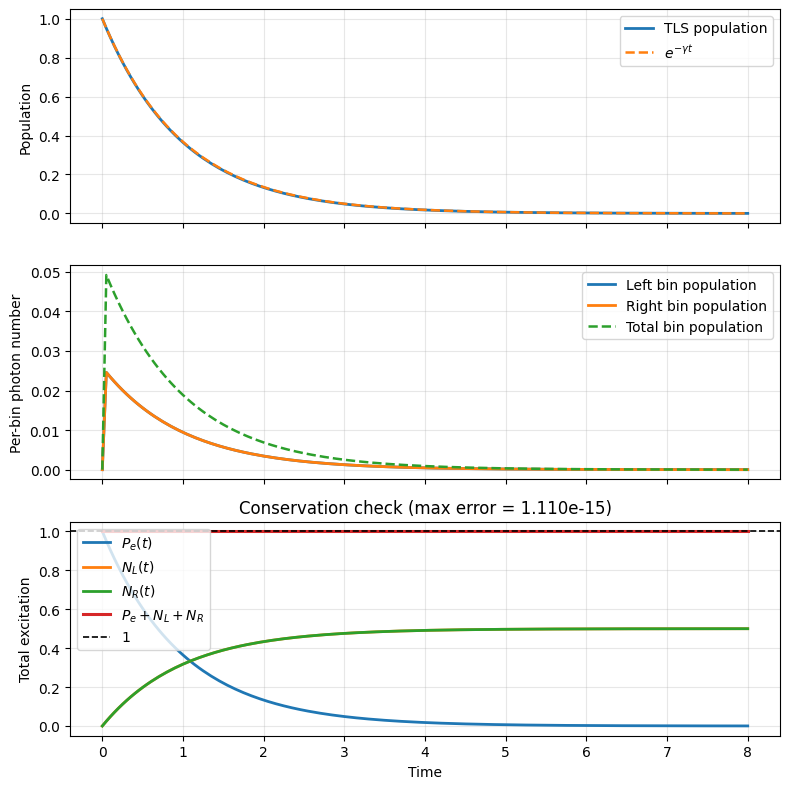

In [1]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
import wqedlib as qmps


def compute_standard_observables(bins: qmps.BinsSeemps, params):
    """
    Standard Qwave-style observables from stored local states.

    Assumes:
    - bins.system_states are valid local normalized tensors
    - bins.output_field_states are also valid local normalized tensors
      (this should hold after scheme B is implemented correctly)
    """
    tls_pop_op = qmps.tls_pop()
    b_pop_l = qmps.num_op_l(params.d_t_total)
    b_pop_r = qmps.num_op_r(params.d_t_total)

    tls_pop = np.asarray(
        qmps.single_time_expectation(bins.system_states, tls_pop_op),
        dtype=float,
    )

    photon_bins = np.asarray(
        qmps.single_time_expectation(
            bins.output_field_states,
            [b_pop_l, b_pop_r],
        ),
        dtype=float,
    )

    photon_bins_l = photon_bins[0]
    photon_bins_r = photon_bins[1]

    # output_field_states[0] is the initial input bin before interaction,
    # so it should not be counted as emitted radiation.
    emitted_l = np.concatenate([[0.0], np.cumsum(photon_bins_l[1:])])
    emitted_r = np.concatenate([[0.0], np.cumsum(photon_bins_r[1:])])

    total_excitation = tls_pop + emitted_l + emitted_r

    return {
        "times": np.asarray(bins.times, dtype=float),
        "tls_pop": tls_pop,
        "photon_bins_l": photon_bins_l,
        "photon_bins_r": photon_bins_r,
        "emitted_l": emitted_l,
        "emitted_r": emitted_r,
        "total_excitation": total_excitation,
        "max_abs_error": float(np.max(np.abs(total_excitation - 1.0))),
    }


def plot_standard_observables(bins: qmps.BinsSeemps, params):
    obs = compute_standard_observables(bins, params)
    t = obs["times"]
    gamma_total = params.gamma_l + params.gamma_r

    fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

    axes[0].plot(t, obs["tls_pop"], lw=2, label="TLS population")
    axes[0].plot(t, np.exp(-gamma_total * t), "--", lw=1.8, label=rf"$e^{{-\gamma t}}$")
    axes[0].set_ylabel("Population")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(t, obs["photon_bins_l"], lw=2, label="Left bin population")
    axes[1].plot(t, obs["photon_bins_r"], lw=2, label="Right bin population")
    axes[1].plot(
        t,
        obs["photon_bins_l"] + obs["photon_bins_r"],
        "--",
        lw=1.8,
        label="Total bin population",
    )
    axes[1].set_ylabel("Per-bin photon number")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    axes[2].plot(t, obs["tls_pop"], lw=2, label=r"$P_e(t)$")
    axes[2].plot(t, obs["emitted_l"], lw=2, label=r"$N_L(t)$")
    axes[2].plot(t, obs["emitted_r"], lw=2, label=r"$N_R(t)$")
    axes[2].plot(t, obs["total_excitation"], lw=2.2, label=r"$P_e+N_L+N_R$")
    axes[2].axhline(1.0, color="k", linestyle="--", lw=1.2, label="1")
    axes[2].set_xlabel("Time")
    axes[2].set_ylabel("Total excitation")
    axes[2].set_title(f"Conservation check (max error = {obs['max_abs_error']:.3e})")
    axes[2].legend()
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    return obs


if __name__ == "__main__":
    params = qmps.parameters.InputParams(
        delta_t=0.05,
        tmax=8.0,
        d_sys_total=np.array([2], dtype=int),
        d_t_total=np.array([2, 2], dtype=int),
        gamma_l=0.5,
        gamma_r=0.5,
        bond_max=18,
    )

    i_s0 = qmps.tls_excited()
    i_n0 = qmps.wg_ground(int(np.prod(params.d_t_total)))

    hm = qmps.atom_waveguide_markov_hamiltonian_lr(params)

    bins = qmps.t_evol_mar_seemps_lr(
        hm,
        i_s0,
        i_n0,
        params,
    )

    # --------------------------------------------------------
    # Check local norms first
    # --------------------------------------------------------
    I_sys = np.eye(int(np.prod(params.d_sys_total)), dtype=complex)
    I_t = np.eye(int(np.prod(params.d_t_total)), dtype=complex)

    print("system norms:")
    for k in range(min(5, len(bins.system_states))):
        print(k, qmps.expectation_1bin(bins.system_states[k], I_sys))

    print("field norms:")
    for k in range(min(5, len(bins.output_field_states))):
        print(k, qmps.expectation_1bin(bins.output_field_states[k], I_t))

    # --------------------------------------------------------
    # Standard observables
    # --------------------------------------------------------
    obs = compute_standard_observables(bins, params)

    print("=" * 72)
    print("times[:8]             =", obs["times"][:8])
    print("tls_pop[:8]           =", obs["tls_pop"][:8])
    print("photon_bins_l[:8]     =", obs["photon_bins_l"][:8])
    print("photon_bins_r[:8]     =", obs["photon_bins_r"][:8])
    print("emitted_l[:8]         =", obs["emitted_l"][:8])
    print("emitted_r[:8]         =", obs["emitted_r"][:8])
    print("total_excitation[:8]  =", obs["total_excitation"][:8])
    print("-" * 72)
    print("final tls_pop         =", obs["tls_pop"][-1])
    print("final emitted_l       =", obs["emitted_l"][-1])
    print("final emitted_r       =", obs["emitted_r"][-1])
    print("final total           =", obs["total_excitation"][-1])
    print("max |total-1|         =", obs["max_abs_error"])
    print("=" * 72)

    plot_standard_observables(bins, params)